In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os

In [6]:
import cv2 
import os 

In [7]:
import matplotlib.pyplot as plt


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Found 0 images belonging to 0 classes.


IndexError: index 0 is out of bounds for axis 0 with size 0

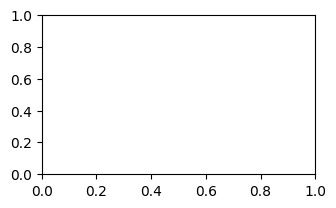

In [9]:
def dataset_train_processing():
    # Hardcode dataset path
    data_path =r'C:\SumMe\Frame\Jumps'
    augmented_data_path = r'C:\SumMe\Augmentation\Augjumps\jumps'
    
    # Create the directory for augmented data if it doesn't exist
    if not os.path.exists(augmented_data_path):
        os.makedirs(augmented_data_path)
    
    # Process dataset
    file_names = os.listdir(data_path)
    
    # Set a datagenerator for augmentation
    train_datagen = ImageDataGenerator(rotation_range=15,
                                       shear_range=0.1,
                                       zoom_range=0.2,
                                       horizontal_flip=True,
                                       width_shift_range=0.1,
                                       height_shift_range=0.1)
    
    # Create batches of data for augmentation
    for file_name in file_names:
        image_path = os.path.join(data_path, file_name)
        img = plt.imread(image_path)
        img = img.reshape((1,) + img.shape)  # Reshape to add batch dimension
        
        # Flow the image through the generator and save augmented images
        i = 0
        for batch in train_datagen.flow(img, 
                                        batch_size=1,
                                        save_to_dir=augmented_data_path,
                                        save_prefix=f'aug_{os.path.splitext(file_name)[0]}',
                                        save_format='jpeg'):
            i += 1
            if i >= 1:  # Save 2 augmented versions of each image
                break
    
    # Sample visualization of augmented images (optional)
    example_gen = train_datagen.flow_from_directory(data_path,
                                                    target_size=(224, 224),
                                                    batch_size=1,
                                                    class_mode=None,
                                                    save_to_dir=augmented_data_path,
                                                    save_prefix='aug_example',
                                                    save_format='jpg')
    
    plt.figure(figsize=(12, 12))
    for i in range(0, 15):
        plt.subplot(5, 3, i + 1)
        for X in example_gen:
            image = X[0]
            plt.imshow(image)
            break
    plt.tight_layout()
    plt.show()

# Usage
dataset_train_processing()

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np
import os

# Load the InceptionV3 model
net = InceptionV3(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\Augjumps'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in InceptionV3 (change as needed)
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'inceptionv3_features_train.npy'), features_train)

print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])


Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 149, 149, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 149, 149, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                      

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os


# Load the ResNet50 model
net = ResNet50(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\Augjumps'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in ResNet50
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'resnet50_features_train.npy'), features_train)


print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

In [12]:
import numpy as np
import os

# Define the directory where your features are saved
image_directory = r'C:\SumMe\Augmentation\Augjumps'

# Load the features from the saved .npy files
features_resnet = np.load(os.path.join(image_directory, 'resnet50_features_train.npy'))
features_inceptionv3 = np.load(os.path.join(image_directory, 'inceptionv3_features_train.npy'))

# Ensure both feature arrays have the same number of samples
assert features_resnet.shape[0] == features_inceptionv3.shape[0], "Number of samples must be the same in both feature arrays."

# Concatenate the features along the feature dimension (axis=1)
features_combined = np.concatenate((features_resnet, features_inceptionv3), axis=1)

# Save the combined features to a new .npy file
np.save(os.path.join(image_directory, 'combined_features_train.npy'), features_combined)

print(f"Combined features shape: {features_combined.shape}")

# Print some sample combined features
print("Sample combined features (first 5 rows):")
print(features_combined[:5])

Combined features shape: (950, 2000)
Sample combined features (first 5 rows):
[[1.0938617e-04 2.7907216e-05 2.6438568e-06 ... 5.7049187e-05
  3.0333060e-04 1.0399620e-04]
 [4.4201461e-06 3.5275618e-06 1.5484463e-06 ... 7.6172677e-05
  2.2052738e-03 3.2843483e-04]
 [1.7339773e-05 1.8673489e-06 1.2717937e-06 ... 7.5548407e-05
  2.9790972e-04 1.1362025e-04]
 [6.7304393e-07 6.6257900e-07 1.4304985e-07 ... 6.5391243e-05
  5.8244768e-04 1.1679276e-04]
 [2.0438076e-05 5.2390401e-06 3.2030343e-06 ... 2.4426446e-04
  6.6898251e-04 3.3402632e-04]]


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [14]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Define the directory where your features are saved
image_directory = r'C:\SumMe\Augmentation\Augjumps'

# Load the features from the saved .npy files
features_combined = np.load(os.path.join(image_directory, 'combined_features_train.npy'))

# Define the number of timesteps (sequence length) and features
timesteps = 1  # Assuming each sample is treated as a sequence of length 1 for this example
input_dim = features_combined.shape[1]  # Should be 2000

# Prepare data for LSTM
# For this example, we'll use the features directly as sequences of length 1
X = features_combined
y = np.random.randint(0, 100, size=(features_combined.shape[0],))  # Example target variable, replace with your actual labels

# Reshape input to be [samples, timesteps, features]
X = X.reshape((X.shape[0], timesteps, input_dim))

# Define the LSTM model
inputs = Input(shape=(timesteps, input_dim))

# Add LSTM layers
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.5)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(32)(x)
x = Dropout(0.5)(x)

# Add a Dense layer for output
outputs = Dense(100, activation='softmax')(x)  # Adjust the number of units based on your specific task

# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model
# For this example, we use dummy targets. Replace y with your actual labels.
model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

# Extract features from the last LSTM layer
feature_extractor = Model(inputs=model.input, outputs=model.layers[-3].output)  # Layer before the final Dense layer

# Obtain features from the last LSTM layer
features_last_lstm = feature_extractor.predict(X)

# Save the extracted features
np.save(os.path.join(image_directory, 'features_last_lstm.npy'), features_last_lstm)

# Print the feature shape
print(f"Shape of features extracted from the last LSTM layer: {features_last_lstm.shape}")

# Print some sample features
print("Sample features from the last LSTM layer (first 5 samples):")
print(features_last_lstm[:5])

Epoch 1/20
24/24 [==============================] - 24s 230ms/step - loss: 4.6054 - accuracy: 0.0079 - val_loss: 4.6051 - val_accuracy: 0.0158
Epoch 2/20
24/24 [==============================] - 1s 46ms/step - loss: 4.6029 - accuracy: 0.0145 - val_loss: 4.6053 - val_accuracy: 0.0158
Epoch 3/20
24/24 [==============================] - 1s 44ms/step - loss: 4.6010 - accuracy: 0.0132 - val_loss: 4.6052 - val_accuracy: 0.0158
Epoch 4/20
24/24 [==============================] - 1s 43ms/step - loss: 4.5988 - accuracy: 0.0158 - val_loss: 4.6057 - val_accuracy: 0.0158
Epoch 5/20
24/24 [==============================] - 1s 43ms/step - loss: 4.5960 - accuracy: 0.0158 - val_loss: 4.6059 - val_accuracy: 0.0158
Epoch 6/20
24/24 [==============================] - 1s 47ms/step - loss: 4.5864 - accuracy: 0.0224 - val_loss: 4.6171 - val_accuracy: 0.0158
Epoch 7/20
24/24 [==============================] - 1s 46ms/step - loss: 4.5800 - accuracy: 0.0105 - val_loss: 4.6413 - val_accuracy: 0.0158
Epoch 8/20


In [15]:
import numpy as np
from sklearn.cluster import KMeans

# Load data (assuming the data is saved in a numpy array .npy file)
# Replace the path with the actual location of your data file
F = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")  # Adjust this path if necessary

# Set parameters
N = 143
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Initialize list to store indices of data points in each cluster
C = {i: np.where(C_IDX == i)[0] for i in range(N)}

# C now contains the indices of data points in each cluster


In [16]:

# Print the actual data points in the first cluster (cluster 0)
cluster_0_data_points = F[C[0], :]
print(cluster_0_data_points)


[[ 0.23334943 -0.36574167  0.07178452 -0.38314232 -0.28883916  0.29243234
  -0.30572265  0.26237723  0.35224625 -0.28662285 -0.44469467 -0.13812299
  -0.26442972  0.38829646 -0.14877878 -0.14569992 -0.1279557   0.11930988
   0.14634635 -0.24424516  0.06694945  0.1827748  -0.01251782 -0.05662621
   0.0687658  -0.21275233 -0.2058778  -0.34445986  0.3533513  -0.3063841
  -0.4195184   0.01672732]
 [ 0.23377143 -0.36616537  0.07186633 -0.38354194 -0.289056    0.29277173
  -0.3060088   0.26267645  0.3527682  -0.28695127 -0.44510713 -0.13848153
  -0.2646352   0.38869083 -0.14884141 -0.14576411 -0.12803774  0.11947467
   0.14641379 -0.24454965  0.06706731  0.18290074 -0.01258887 -0.05658242
   0.06878423 -0.21288691 -0.20620821 -0.3448815   0.35373312 -0.30670223
  -0.42014086  0.01674021]
 [ 0.23229162 -0.36468038  0.07157882 -0.38214195 -0.28829527  0.29158318
  -0.30500522  0.2616281   0.35093784 -0.2857985  -0.44366065 -0.13723
  -0.26391304  0.38730824 -0.14862287 -0.14553632 -0.12774953 

In [17]:
# Print all the indices and their corresponding cluster values
for cluster_idx in range(N):
    print(f"Cluster {cluster_idx}:")
    print("Indices of data points:", C[cluster_idx])
    print("Number of data points in this cluster:", len(C[cluster_idx]))
    print()


Cluster 0:
Indices of data points: [  9 133 202 213 214 324 392 402 414 479 483 517 558 641]
Number of data points in this cluster: 14

Cluster 1:
Indices of data points: [390 513]
Number of data points in this cluster: 2

Cluster 2:
Indices of data points: [ 79 449 536 717 758 784 896]
Number of data points in this cluster: 7

Cluster 3:
Indices of data points: [ 35  91 175 192 199 223 225 234 252 623 817]
Number of data points in this cluster: 11

Cluster 4:
Indices of data points: [367 482 593 683]
Number of data points in this cluster: 4

Cluster 5:
Indices of data points: [ 52 458 508 590 695 737 871]
Number of data points in this cluster: 7

Cluster 6:
Indices of data points: [171 450 905]
Number of data points in this cluster: 3

Cluster 7:
Indices of data points: [ 22 572 619 839 867]
Number of data points in this cluster: 5

Cluster 8:
Indices of data points: [269 540 565 892]
Number of data points in this cluster: 4

Cluster 9:
Indices of data points: [132 138 150 187 191 197

In [18]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# Load data (assuming the data is saved in a numpy array .npy file)
try:
    F = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")  # Adjust this path if necessary
except FileNotFoundError:
    print("Error: The specified file was not found.")
    exit(1)

# Set parameters
N = 143  # Number of clusters
num_samples = F.shape[0]  # Number of data points (950)
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Initialize binary matrix (950 x 143) with zeros
keyframe_matrix = np.zeros((num_samples, N), dtype=int)

# Loop through each cluster and find the closest data point to the centroid
for cluster_idx in range(N):
    # Get the indices of the data points in the current cluster
    cluster_indices = np.where(C_IDX == cluster_idx)[0]
    
    # Skip empty clusters (if any)
    if len(cluster_indices) == 0:
        print(f"Cluster {cluster_idx} is empty, skipping.")
        continue
    
    # Get the feature vectors for the data points in this cluster
    cluster_features = F[cluster_indices, :]
    
    # Get the centroid of this cluster
    centroid = CC[cluster_idx]
    
    # Compute the Euclidean distance between each point in the cluster and the centroid
    distances = cdist(cluster_features, centroid.reshape(1, -1), metric='euclidean')
    
    # Get the index of the closest data point to the centroid
    closest_point_idx = cluster_indices[np.argmin(distances)]
    
    # Set the corresponding entry in the binary matrix to 1 (keyframe)
    keyframe_matrix[closest_point_idx, cluster_idx] = 1

    # Optionally, print the keyframe index for each cluster
    print(f"Cluster {cluster_idx}: Keyframe index: {closest_point_idx}")
# keyframe_matrix is now a 950 x 143 binary matrix
# You can use it for further analysis or saving to a file


Cluster 0: Keyframe index: 414
Cluster 1: Keyframe index: 513
Cluster 2: Keyframe index: 896
Cluster 3: Keyframe index: 192
Cluster 4: Keyframe index: 593
Cluster 5: Keyframe index: 871
Cluster 6: Keyframe index: 450
Cluster 7: Keyframe index: 619
Cluster 8: Keyframe index: 892
Cluster 9: Keyframe index: 330
Cluster 10: Keyframe index: 665
Cluster 11: Keyframe index: 251
Cluster 12: Keyframe index: 729
Cluster 13: Keyframe index: 688
Cluster 14: Keyframe index: 530
Cluster 15: Keyframe index: 764
Cluster 16: Keyframe index: 854
Cluster 17: Keyframe index: 261
Cluster 18: Keyframe index: 454
Cluster 19: Keyframe index: 263
Cluster 20: Keyframe index: 344
Cluster 21: Keyframe index: 400
Cluster 22: Keyframe index: 938
Cluster 23: Keyframe index: 570
Cluster 24: Keyframe index: 907
Cluster 25: Keyframe index: 29
Cluster 26: Keyframe index: 661
Cluster 27: Keyframe index: 798
Cluster 28: Keyframe index: 917
Cluster 29: Keyframe index: 578
Cluster 30: Keyframe index: 924
Cluster 31: Keyfram

In [19]:
# Save the keyframe binary matrix
np.save(r'C:\SumMe\Augmentation\Augjumps\keyframe.npy', keyframe_matrix)

In [20]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.io import savemat

# Load data (assuming the data is saved in a numpy array .npy file)
try:
    F = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")  # Adjust this path if necessary
except FileNotFoundError:
    print("Error: The specified file was not found.")
    exit(1)

# Check shape of input data
print("Shape of input data F:", F.shape)

# Set parameters
N = 143 # Number of clusters
num_samples = F.shape[0]  # Number of data points (should be 950)
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', n_init=50, random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Check cluster assignments
unique, counts = np.unique(C_IDX, return_counts=True)
cluster_sizes = dict(zip(unique, counts))
print("Cluster sizes:", cluster_sizes)

# Initialize binary matrix (950 x 143) with zeros
keyframe_matrix = np.zeros((num_samples, N), dtype=int)

# Loop through each cluster and find the closest data point to the centroid
for cluster_idx in range(N):
    # Get the indices of the data points in the current cluster
    cluster_indices = np.where(C_IDX == cluster_idx)[0]
    
    # Skip empty clusters (if any)
    if len(cluster_indices) == 0:
        print(f"Warning: Cluster {cluster_idx} is empty, skipping.")
        continue
    
    # Get the feature vectors for the data points in this cluster
    cluster_features = F[cluster_indices, :]
    
    # Get the centroid of this cluster
    centroid = CC[cluster_idx]
    
    # Compute the Euclidean distance between each point in the cluster and the centroid
    distances = cdist(cluster_features, centroid.reshape(1, -1), metric='euclidean')
    
    # Get the index of the closest data point to the centroid
    closest_point_idx = cluster_indices[np.argmin(distances)]
    
    # Set the corresponding entry in the binary matrix to 1 (keyframe)
    keyframe_matrix[closest_point_idx, cluster_idx] = 1

# Check the shape of the keyframe matrix
print("Shape of keyframe matrix:", keyframe_matrix.shape)

# Save the matrix as a .mat file
savemat(r'C:\SumMe\Augmentation\Augjumps\keyframe_matrix.mat', {'keyframe_matrix': keyframe_matrix})


Shape of input data F: (950, 32)
Cluster sizes: {0: 7, 1: 4, 2: 6, 3: 4, 4: 16, 5: 4, 6: 7, 7: 11, 8: 6, 9: 7, 10: 15, 11: 4, 12: 11, 13: 6, 14: 5, 15: 7, 16: 12, 17: 4, 18: 3, 19: 8, 20: 7, 21: 8, 22: 4, 23: 5, 24: 9, 25: 5, 26: 9, 27: 17, 28: 4, 29: 5, 30: 24, 31: 7, 32: 7, 33: 9, 34: 6, 35: 8, 36: 4, 37: 13, 38: 2, 39: 5, 40: 11, 41: 3, 42: 5, 43: 4, 44: 11, 45: 7, 46: 5, 47: 7, 48: 9, 49: 3, 50: 7, 51: 13, 52: 5, 53: 7, 54: 5, 55: 4, 56: 1, 57: 4, 58: 9, 59: 4, 60: 19, 61: 10, 62: 7, 63: 16, 64: 5, 65: 8, 66: 2, 67: 7, 68: 11, 69: 5, 70: 8, 71: 12, 72: 5, 73: 6, 74: 5, 75: 6, 76: 4, 77: 3, 78: 3, 79: 8, 80: 5, 81: 4, 82: 15, 83: 4, 84: 5, 85: 4, 86: 9, 87: 10, 88: 10, 89: 7, 90: 12, 91: 8, 92: 2, 93: 5, 94: 6, 95: 8, 96: 10, 97: 1, 98: 7, 99: 9, 100: 2, 101: 3, 102: 12, 103: 3, 104: 4, 105: 5, 106: 7, 107: 8, 108: 8, 109: 3, 110: 5, 111: 9, 112: 4, 113: 4, 114: 14, 115: 2, 116: 1, 117: 7, 118: 7, 119: 3, 120: 6, 121: 2, 122: 10, 123: 1, 124: 3, 125: 1, 126: 1, 127: 3, 128: 3, 129: 

In [1]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")

# Step 2: (Optional) Preprocess the data if needed
# For example, you might want to scale the features to ensure the clustering works well
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Perform Agglomerative Clustering
# You can specify the number of clusters or other hyperparameters here
n_clusters = 143  # Example, set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model to the feature matrix
clustering_labels = clustering.fit_predict(features_scaled)

# Step 4: (Optional) Visualize the results if the features are 2D (or use dimensionality reduction)
if features_scaled.shape[1] == 2:  # If your features are 2D, you can visualize them
    plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=clustering_labels, cmap='viridis')
    plt.title("Agglomerative Clustering Results")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# If you have higher-dimensional features, consider using PCA to reduce to 2D for visualization
# For example:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# features_2d = pca.fit_transform(features_scaled)
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clustering_labels, cmap='viridis')
# plt.show()

# Step 5: View the labels assigned to each data point
print("Cluster Labels:", clustering_labels)

Cluster Labels: [ 38 100  12  63   4  86  59 135  88  82  39 102   4  33  91  43 106  31
  91  97   5  17  41  32  26  44 133 123  33 139   7 126  65  76  84  99
 130 141  52  76  76  77 117  26  96  53  53  60 105  40  77  80  62  97
  97 140  23  32  81  19 127  17  86  22 110  46 142  21 118  51   1 107
  64 138 125  45  28  15  25  73 129  36   8 110   8  20 105  16  38  64
 119  54  48  52  48  98  79 105  45  97  67  76  21 103  11 138 103  24
  16  52  38  16  45  53  24 109  45  80  92  28   8  64  60  57  53  51
  67   0  21  36 117  24   8 118  23  79  53  67   8  52   0  58  45 130
  86 110 138  80   0 127  77  80 130  81  57 129 103  76  80   1   1  80
 109  11  58  22  91  16  85 129  28  30  98 119  24  54 127  23  28 105
 118   8  77  98  80 117 127   8  12 110  81  77  54  36  21   1   0  77
  85  54 110  85  82  45 119  81  35  79 118  11   8   0 125  82 118  52
  51  28   1 138 130  29  20  54  45  99  11  81  53 109  21  70  79 110
  54  58  21  89  67  67 114 105 12

In [2]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =143  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 38:
Indices of data points: [0, 88, 110, 276, 874, 932, 935, 937]
Number of data points in this cluster: 8

Cluster 100:
Indices of data points: [1, 356, 491, 615, 799]
Number of data points in this cluster: 5

Cluster 12:
Indices of data points: [2, 188, 370, 519, 561, 563, 795, 928]
Number of data points in this cluster: 8

Cluster 63:
Indices of data points: [3, 247, 692, 786, 903]
Number of data points in this cluster: 5

Cluster 4:
Indices of data points: [4, 12, 255, 265, 333, 385, 523, 872, 931, 943]
Number of data points in this cluster: 10

Cluster 86:
Indices of data points: [5, 62, 144, 368, 463, 533, 746, 807]
Number of data points in this cluster: 8

Cluster 59:
Indices of data points: [6, 291, 362, 511, 538, 583, 709, 810, 825]
Number of data points in this cluster: 9

Cluster 135:
Indices of data points: [7, 559]
Number of data points in this cluster: 2

Cluster 88:
Indices of data points: [8, 832]
Number of data points in this cluster: 2

Cluster 82:
Indices of 

In [3]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")

# Step 2: (Optional) Preprocess the data if needed
# For example, you might want to scale the features to ensure the clustering works well
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Perform Agglomerative Clustering
# You can specify the number of clusters or other hyperparameters here
n_clusters = 143  # Example, set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model to the feature matrix
clustering_labels = clustering.fit_predict(features_scaled)

# Step 4: (Optional) Visualize the results if the features are 2D (or use dimensionality reduction)
if features_scaled.shape[1] == 2:  # If your features are 2D, you can visualize them
    plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=clustering_labels, cmap='viridis')
    plt.title("Agglomerative Clustering Results")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# If you have higher-dimensional features, consider using PCA to reduce to 2D for visualization
# For example:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# features_2d = pca.fit_transform(features_scaled)
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clustering_labels, cmap='viridis')
# plt.show()

# Step 5: View the labels assigned to each data point
print("Cluster Labels:", clustering_labels)

Cluster Labels: [ 38 100  12  63   4  86  59 135  88  82  39 102   4  33  91  43 106  31
  91  97   5  17  41  32  26  44 133 123  33 139   7 126  65  76  84  99
 130 141  52  76  76  77 117  26  96  53  53  60 105  40  77  80  62  97
  97 140  23  32  81  19 127  17  86  22 110  46 142  21 118  51   1 107
  64 138 125  45  28  15  25  73 129  36   8 110   8  20 105  16  38  64
 119  54  48  52  48  98  79 105  45  97  67  76  21 103  11 138 103  24
  16  52  38  16  45  53  24 109  45  80  92  28   8  64  60  57  53  51
  67   0  21  36 117  24   8 118  23  79  53  67   8  52   0  58  45 130
  86 110 138  80   0 127  77  80 130  81  57 129 103  76  80   1   1  80
 109  11  58  22  91  16  85 129  28  30  98 119  24  54 127  23  28 105
 118   8  77  98  80 117 127   8  12 110  81  77  54  36  21   1   0  77
  85  54 110  85  82  45 119  81  35  79 118  11   8   0 125  82 118  52
  51  28   1 138 130  29  20  54  45  99  11  81  53 109  21  70  79 110
  54  58  21  89  67  67 114 105 12

In [4]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =143  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 38:
Indices of data points: [0, 88, 110, 276, 874, 932, 935, 937]
Number of data points in this cluster: 8

Cluster 100:
Indices of data points: [1, 356, 491, 615, 799]
Number of data points in this cluster: 5

Cluster 12:
Indices of data points: [2, 188, 370, 519, 561, 563, 795, 928]
Number of data points in this cluster: 8

Cluster 63:
Indices of data points: [3, 247, 692, 786, 903]
Number of data points in this cluster: 5

Cluster 4:
Indices of data points: [4, 12, 255, 265, 333, 385, 523, 872, 931, 943]
Number of data points in this cluster: 10

Cluster 86:
Indices of data points: [5, 62, 144, 368, 463, 533, 746, 807]
Number of data points in this cluster: 8

Cluster 59:
Indices of data points: [6, 291, 362, 511, 538, 583, 709, 810, 825]
Number of data points in this cluster: 9

Cluster 135:
Indices of data points: [7, 559]
Number of data points in this cluster: 2

Cluster 88:
Indices of data points: [8, 832]
Number of data points in this cluster: 2

Cluster 82:
Indices of 

In [5]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters = 143  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Function to get the keyframe index (centroid-based approach)
def get_keyframe_for_cluster(cluster_indices):
    # Extract the features for the current cluster
    cluster_features = features_scaled[cluster_indices]
    
    # Compute the centroid of the cluster (mean of the features)
    centroid = np.mean(cluster_features, axis=0)
    
    # Calculate the distance from each point to the centroid
    distances = cdist([centroid], cluster_features)
    
    # Get the index of the point closest to the centroid
    keyframe_index = cluster_indices[np.argmin(distances)]
    return keyframe_index

# Generate and display the sequence of keyframe indices for each cluster
keyframe_sequence = []

for cluster_label, indices in cluster_dict.items():
    keyframe_index = get_keyframe_for_cluster(indices)
    keyframe_sequence.append((cluster_label, keyframe_index))

# Print the sequence of keyframes in the desired format
for cluster_label, keyframe_index in keyframe_sequence:
    print(f"Cluster {cluster_label}: Keyframe index: {keyframe_index}")

Cluster 38: Keyframe index: 276
Cluster 100: Keyframe index: 1
Cluster 12: Keyframe index: 561
Cluster 63: Keyframe index: 786
Cluster 4: Keyframe index: 265
Cluster 86: Keyframe index: 746
Cluster 59: Keyframe index: 291
Cluster 135: Keyframe index: 7
Cluster 88: Keyframe index: 8
Cluster 82: Keyframe index: 213
Cluster 39: Keyframe index: 665
Cluster 102: Keyframe index: 11
Cluster 33: Keyframe index: 244
Cluster 91: Keyframe index: 18
Cluster 43: Keyframe index: 689
Cluster 106: Keyframe index: 653
Cluster 31: Keyframe index: 271
Cluster 97: Keyframe index: 578
Cluster 5: Keyframe index: 606
Cluster 17: Keyframe index: 782
Cluster 41: Keyframe index: 619
Cluster 32: Keyframe index: 23
Cluster 26: Keyframe index: 43
Cluster 44: Keyframe index: 441
Cluster 133: Keyframe index: 464
Cluster 123: Keyframe index: 27
Cluster 139: Keyframe index: 394
Cluster 7: Keyframe index: 30
Cluster 126: Keyframe index: 611
Cluster 65: Keyframe index: 851
Cluster 76: Keyframe index: 337
Cluster 84: Key

In [6]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.io import savemat  # Import savemat to save in .mat format
import pandas as pd  # Import pandas for CSV file export

# Load the LSTM features from the .npy file
lstm_features = np.load(r"C:\SumMe\Augmentation\Augjumps\features_last_lstm.npy")

# Flatten LSTM features for clustering (if necessary)
n_samples = lstm_features.shape[0]  # Define the number of samples
n_clusters = 143  # Set the number of clusters
lstm_features_flattened = lstm_features.reshape(n_samples, -1)

# Standardizing the data before clustering
scaler = StandardScaler()
lstm_features_scaled = scaler.fit_transform(lstm_features_flattened)

# Apply Agglomerative Clustering with 'ward' linkage (no need to specify affinity)
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels = agg_clustering.fit_predict(lstm_features_scaled)

# Group data points by cluster
clustered_data = {}

for idx, label in enumerate(labels):
    if label not in clustered_data:
        clustered_data[label] = []
    clustered_data[label].append(idx)

# Find keyframe for each cluster
keyframes = {}

for cluster_id, indices in clustered_data.items():
    # Get the feature vectors for the data points in this cluster
    cluster_features = lstm_features_scaled[indices]
    
    # Compute the centroid of the cluster (average of all feature vectors in the cluster)
    centroid = np.mean(cluster_features, axis=0)
    
    # Compute the Euclidean distance from each data point to the centroid
    distances = cdist(cluster_features, [centroid], metric='euclidean')
    
    # Find the index of the closest data point (keyframe)
    keyframe_idx = indices[np.argmin(distances)]
    
    # Store the keyframe index for the cluster
    keyframes[cluster_id] = keyframe_idx

# Create a binary matrix of shape (n_samples, n_clusters)
keyframe_matrix = np.zeros((n_samples, n_clusters), dtype=int)

# Mark the keyframes (set the corresponding index to 1)
for cluster_id, keyframe_idx in keyframes.items():
    keyframe_matrix[keyframe_idx, cluster_id] = 1

# Save the keyframe binary matrix as a .mat file
keyframe_data = {'keyframe_matrix': keyframe_matrix}  # Create a dictionary to save in .mat format
savemat(r'C:\SumMe\Augmentation\Augjumps\features_last_lstm1.mat', keyframe_data)

# Print confirmation for .mat file
print(f"Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.mat")
print(f"Dimensions of the keyframe binary matrix: {keyframe_matrix.shape}")

# Save the keyframe binary matrix as a .csv file
keyframe_matrix_df = pd.DataFrame(keyframe_matrix)  # Convert matrix to DataFrame
keyframe_matrix_df.to_csv(r'C:\SumMe\Augmentation\Augjumps\features_last_lstm1.csv', index=False)

# Print confirmation for .csv file
print(f"Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.csv")

# Print the sequence of keyframe indices in order of cluster numbers (Cluster 0, Cluster 1, ..., Cluster n)
print("\nKeyframe indices for each cluster:")
for cluster_id in range(n_clusters):
    if cluster_id in keyframes:
        print(f"Cluster {cluster_id}: Keyframe Index {keyframes[cluster_id]}")
    else:
        print(f"Cluster {cluster_id}: No keyframe found")

Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.mat
Dimensions of the keyframe binary matrix: (950, 143)
Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.csv

Keyframe indices for each cluster:
Cluster 0: Keyframe Index 526
Cluster 1: Keyframe Index 718
Cluster 2: Keyframe Index 453
Cluster 3: Keyframe Index 649
Cluster 4: Keyframe Index 265
Cluster 5: Keyframe Index 606
Cluster 6: Keyframe Index 593
Cluster 7: Keyframe Index 30
Cluster 8: Keyframe Index 132
Cluster 9: Keyframe Index 639
Cluster 10: Keyframe Index 927
Cluster 11: Keyframe Index 917
Cluster 12: Keyframe Index 561
Cluster 13: Keyframe Index 798
Cluster 14: Keyframe Index 605
Cluster 15: Keyframe Index 273
Cluster 16: Keyframe Index 87
Cluster 17: Keyframe Index 782
Cluster 18: Keyframe Index 845
Cluster 19: Keyframe Index 288
Cluster 20: Keyframe Index 474
Cluster 21: Keyframe Index 636
Cluster 22: Keyframe Index 290
Cluster 23: Keyframe Index 790
Cluster 24: Keyframe 

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import scipy.io

# Step 1: Load the annotator labels from the .mat file
annotator_path = r"C:\SumMe\GT\Jumps.mat" # Path to the .mat file
mat_data = scipy.io.loadmat(annotator_path)

# Check the keys in the .mat file
print("Keys in the .mat file:", mat_data.keys())


user_scores = mat_data['user_score']  
print(f"Shape of user_score: {user_scores.shape}")

# Step 2: Load our model's predictions from the .csv file
our_path = r"C:\SumMe\Augmentation\Augjumps\features_last_lstm1.csv" # Path to the CSV file
u1 = pd.read_csv(our_path, header=None).values.flatten()  # Our model's predictions (binary array)


print(f"Shape of model's predictions (u1): {u1.shape}")

# Ensure that the length of u1 matches the number of rows in user_scores
if u1.shape[0] != user_scores.shape[0]:
    print(f"Warning: Mismatched lengths. Adjusting the data...")
    u1 = u1[:user_scores.shape[0]]  # Truncate u1 to match the number of rows in user_scores

# Step 3: Ensure both u1 and user_scores are binary (logical values, 0 or 1)
u1 = u1.astype(bool)

# Step 4: Compute the F1-Score for each of the 15 datasets (columns in user_scores)
f1_scores = []  # List to store F1 scores for each dataset

for i in range(user_scores.shape[1]):  # Loop through the 15 columns
    u2 = user_scores[:, i]  # Extract the i-th column (ground truth labels for the i-th dataset)
    
    # Ensure u2 is a boolean array
    u2 = u2.astype(bool)
    
    # Step 5: Compute the confusion matrix
    cm = confusion_matrix(u2, u1)
    
    # Extract the confusion matrix components
    tn, fp, fn, tp = cm.ravel()  # Unpack the confusion matrix
    
    # Debugging step: Print confusion matrix for the 4th column
    if i == 3:  # Checking the 4th column
        print(f"Confusion Matrix for user_score column {i+1} (4th column):")
        print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    
    # Check for zero denominators and calculate Precision, Recall, and F1-Score safely
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # F1 Score is calculated if both precision and recall are non-zero, otherwise it's 0 or nan
    if precision + recall > 0:
        fscore = 2 * (precision * recall) / (precision + recall)
    else:
        fscore = 0.0  # F1 score is 0 if either precision or recall is zero
    
    f1_scores.append(fscore)  # Append F1 score for this dataset
    
    # Print the F1 Score for this dataset
    print(f"\nF1-Score for user_score column {i+1}: {fscore:.4f}")

# Step 6: Output all the F1 scores for the 15 datasets
print("\nAll F1 Scores:")
for i, score in enumerate(f1_scores, 1):
    print(f"F1 Score for user_score column {i}: {score:.4f}")

Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'all_userIDs', 'segments', 'nFrames', 'video_duration', 'FPS', 'gt_score', 'user_score'])
Shape of user_score: (950, 15)
Shape of model's predictions (u1): (135993,)

F1-Score for user_score column 1: 0.2552

F1-Score for user_score column 2: 0.2405

F1-Score for user_score column 3: 0.1891
Confusion Matrix for user_score column 4 (4th column):
TN: 660, FP: 143, FN: 147, TP: 0

F1-Score for user_score column 4: 0.0000

F1-Score for user_score column 5: 0.0000

F1-Score for user_score column 6: 0.3346

F1-Score for user_score column 7: 0.0000

F1-Score for user_score column 8: 0.0000

F1-Score for user_score column 9: 0.0070

F1-Score for user_score column 10: 0.2276

F1-Score for user_score column 11: 0.1931

F1-Score for user_score column 12: 0.1375

F1-Score for user_score column 13: 0.5121

F1-Score for user_score column 14: 0.1869

F1-Score for user_score column 15: 0.3359

All F1 Scores:
F1 Score for use